In [1]:
import tensorflow as tf 
from tensorflow.keras.preprocessing.image import ImageDataGenerator 
from tensorflow.keras.applications import EfficientNetB0 
from tensorflow.keras import layers, models 
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint 
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
train_dir = "../smartvision_dataset/classification/train"
val_dir = "../smartvision_dataset/classification/val"
test_dir = "../smartvision_dataset/classification/test"

In [3]:
img_size = (224, 224)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical"
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

Found 1749 images belonging to 25 classes.
Found 375 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [4]:
num_classes = train_data.num_classes

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(num_classes, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=output)

In [5]:
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3),
    ModelCheckpoint("../models/efficientnet_best.h5", save_best_only=True)
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=loss_fn,
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0585 - loss: 6.6396

55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.0640 - loss: 6.4487 - val_accuracy: 0.1147 - val_loss: 5.4512 - learning_rate: 1.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.0866 - loss: 5.9717

55/55 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.1058 - loss: 5.8720 - val_accuracy: 0.2187 - val_loss: 5.2143 - learning_rate: 1.0000e-04
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.1696 - loss: 5.5789

55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.1887 - loss: 5.4919 - val_accuracy: 0.3360 - val_loss: 4.9643 - learning_rate: 1.0000e-04
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.2281 - loss: 5.2287

55/55 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.2510 - loss: 5.1563 - val_accuracy: 0.4133 - val_loss: 4.7294 - learning_rate: 1.0000e-04
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3221 - loss: 4.8950

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6804 - loss: 3.2227 - val_accuracy: 0.7093 - val_loss: 3.1868 - learning_rate: 1.0000e-04
Epoch 27/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6745 - loss: 3.1504

55/55 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6770 - loss: 3.1560 - val_accuracy: 0.7093 - val_loss: 3.1488 - learning_rate: 1.0000e-04
Epoch 28/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6982 - loss: 3.1386

55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6970 - loss: 3.1292 - val_accuracy: 0.7067 - val_loss: 3.1131 - learning_rate: 1.0000e-04
Epoch 29/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6953 - loss: 3.0807

55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.6941 - loss: 3.0725 - val_accuracy: 0.7200 - val_loss: 3.0800 - learning_rate: 1.0000e-04
Epoch 30/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7015 - loss: 3.0702

55/55 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.7061 - loss: 3.0327 - val_accuracy: 0.7227 - val_loss: 3.0469 - learning_rate: 1.0000e-04


In [6]:
for layer in base_model.layers[-10:]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=loss_fn,
    metrics=['accuracy']
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6992 - loss: 3.0302

55/55 ━━━━━━━━━━━━━━━━━━━━ 121s 2s/step - accuracy: 0.6993 - loss: 3.0303 - val_accuracy: 0.7147 - val_loss: 3.0116 - learning_rate: 1.0000e-04
Epoch 2/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7059 - loss: 2.9732

55/55 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.7198 - loss: 2.9267 - val_accuracy: 0.7333 - val_loss: 2.9522 - learning_rate: 1.0000e-04
Epoch 3/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7076 - loss: 2.9201

55/55 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.7256 - loss: 2.8733 - val_accuracy: 0.7333 - val_loss: 2.8977 - learning_rate: 1.0000e-04
Epoch 4/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7528 - loss: 2.8042

55/55 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.7513 - loss: 2.7893 - val_accuracy: 0.7307 - val_loss: 2.8473 - learning_rate: 1.0000e-04
Epoch 5/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7625 - loss: 2.7300

...

55/55 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.8937 - loss: 1.9139 - val_accuracy: 0.7680 - val_loss: 2.2003 - learning_rate: 1.0000e-04
Epoch 27/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9013 - loss: 1.8696

55/55 ━━━━━━━━━━━━━━━━━━━━ 97s 2s/step - accuracy: 0.9017 - loss: 1.8626 - val_accuracy: 0.7760 - val_loss: 2.1651 - learning_rate: 1.0000e-04
Epoch 28/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8979 - loss: 1.8572

55/55 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.9022 - loss: 1.8533 - val_accuracy: 0.7760 - val_loss: 2.1508 - learning_rate: 1.0000e-04
Epoch 29/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8986 - loss: 1.8329

55/55 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.8982 - loss: 1.8245 - val_accuracy: 0.7787 - val_loss: 2.1292 - learning_rate: 1.0000e-04
Epoch 30/30
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9106 - loss: 1.8002

55/55 ━━━━━━━━━━━━━━━━━━━━ 98s 2s/step - accuracy: 0.9125 - loss: 1.8027 - val_accuracy: 0.7707 - val_loss: 2.1097 - learning_rate: 1.0000e-04


- Train accuracy is 91%

In [7]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Accuracy:", test_acc)

12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.8347 - loss: 1.9540
Test Accuracy: 0.8346666693687439


- Test accuracy is 83%

In [8]:
model = models.load_model("../models/efficientnet_best.h5")
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes
print(classification_report(y_true, y_pred_classes, target_names=list(test_data.class_indices.keys())))

12/12 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step
               precision    recall  f1-score   support

     airplane       1.00      1.00      1.00        15
          bed       0.82      0.60      0.69        15
        bench       0.88      0.93      0.90        15
      bicycle       0.93      0.87      0.90        15
         bird       1.00      0.87      0.93        15
       bottle       0.88      0.93      0.90        15
         bowl       0.59      0.67      0.62        15
          bus       0.87      0.87      0.87        15
         cake       1.00      0.80      0.89        15
          car       0.74      0.93      0.82        15
          cat       0.67      0.93      0.78        15
        chair       0.79      1.00      0.88        15
        couch       0.71      0.33      0.45        15
          cow       0.88      0.93      0.90        15
          cup       0.85      0.73      0.79        15
          dog       0.77      0.67      0.71        15
     elephant       0.94 

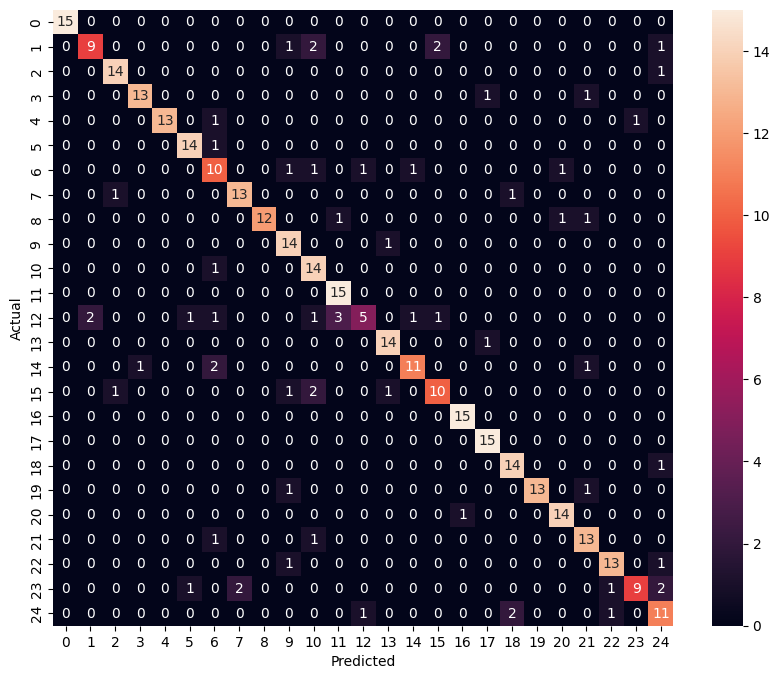

In [9]:
cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()